# Week 4 Coding

Three tasks, each connected to the problem set: **C1** ↔ P3/P4, **C2** ↔ P10, **C3** ↔ P2.

**Predict first.** Before running any check cell, write down on paper what the output will be.

**How to work in this notebook.** Execute the cells in order with Shift+Enter. Each task has a cell with gaps marked `...`: fill them, run the cell, then execute the check cell below it. A passing check prints a confirmation; a failing one raises an `AssertionError`.

## C1: The two discretizations as functions *(↔ P3, P4)*

The Euler discretization is a single line; the exact discretization assembles the augmented matrix $M = \bigl[\begin{smallmatrix} A_c & B_c \\ 0 & 0 \end{smallmatrix}\bigr]$, calls `expm` once, and reads $A_d$ and $B_d$ off the top blocks of $e^{MT_s}$.

a) Complete `euler` and `exact`.

b) The check cell compares the functions with the hand results of P3 (Euler on the mass-spring-damper) and P4 (exact on the RC low-pass), and applies the exact discretization to the tank of Block 1, for which the result contains no exponential.

In [1]:
import numpy as np
from scipy.linalg import expm

def euler(A_c, B_c, T_s):
    """Euler discretization: A_d = I + T_s A_c, B_d = T_s B_c."""
    n = A_c.shape[0]
    A_d = np.eye(n) + T_s * A_c
    B_d = T_s * B_c
    return A_d, B_d

def exact(A_c, B_c, T_s):
    """Exact discretization: the top blocks of expm(M T_s), M the augmented matrix."""
    n, m = A_c.shape[0], B_c.shape[1]
    M = np.zeros((n + m, n + m))
    M[:n, :n], M[:n, n:] = A_c, B_c
    eM = expm(M * T_s)
    A_d = eM[:n, :n]
    B_d = eM[:n, n:]
    return A_d, B_d 

A_msd = np.array([[0., 1.], [-2., -3.]]); B_msd = np.array([[0.], [1.]])   # P3
A_rc = np.array([[-0.5]]); B_rc = np.array([[0.5]])                       # P4
print(euler(A_msd, B_msd, 0.1)[0])
print(exact(A_rc, B_rc, 0.2))

[[ 1.   0.1]
 [-0.2  0.7]]
(array([[0.90483742]]), array([[0.09516258]]))


In [ ]:
Ad, Bd = euler(A_msd, B_msd, 0.1)
assert np.allclose(Ad, [[1, 0.1], [-0.2, 0.7]]) and np.allclose(Bd, [[0], [0.1]])     # P3
ad, bd = exact(A_rc, B_rc, 0.2)
assert abs(ad.item() - np.exp(-0.1)) < 1e-12 and abs(bd.item() - (1 - np.exp(-0.1))) < 1e-12   # P4, P9
At, Bt = exact(np.zeros((1, 1)), np.array([[1.]]), 0.3)
assert At.item() == 1.0 and abs(Bt.item() - 0.3) < 1e-12                                 # the tank of Block 1: A_d = 1, B_d = T_s
print("C1 passed: Euler reproduces P3; exact reproduces P4 (0.905, 0.095) and the tank (1, T_s).")

C1 passed: Euler reproduces P3; exact reproduces P4 (0.905, 0.095) and the tank (1, T_s).


## C2: Euler across the step-size threshold *(↔ P10)*

The input-free Euler recursion $q[n+1] = (1 + T_s a)\,q[n]$ of the heater ($a = -2$) is iterated for five step sizes on both sides of the threshold $2/|a| = 1$.

a) Before running, write down $a_d = 1 - 2T_s$ for each of the five step sizes and the predicted behaviour from P10 b: monotone decay, decaying oscillation, oscillation without decay, or growing oscillation.

b) Complete the recursion, then run the check cell and the plot cell. The run with $T_s = 1.5$ reproduces the sequence $1, -2, 4, -8, \dots$ of Block 2's ConcepTest 1; the run with $T_s = 0.9$ decays yet changes sign at every sample.

In [3]:
a, q0 = -2.0, 1.0                       # stable CT heater

def euler_sim(a, T_s, N):
    q = np.empty(N); q[0] = q0
    for n in range(N - 1):
        q[n + 1] = (1 + T_s * a) * q[n]
    return q

for T_s in (0.1, 0.9, 1.0, 1.1, 1.5):
    q = euler_sim(a, T_s, 25)
    print(f"T_s={T_s}: a_d={1+T_s*a:+.2f}  max|q|={np.max(np.abs(q)):10.1f}")

T_s=0.1: a_d=+0.80  max|q|=       1.0
T_s=0.9: a_d=-0.80  max|q|=       1.0
T_s=1.0: a_d=-1.00  max|q|=       1.0
T_s=1.1: a_d=-1.20  max|q|=      79.5
T_s=1.5: a_d=-2.00  max|q|=16777216.0


In [4]:
assert np.allclose(euler_sim(a, 1.5, 5), [1, -2, 4, -8, 16])          # Block 2, ConcepTest 1
q09 = euler_sim(a, 0.9, 25)
assert np.max(np.abs(q09)) <= 1 and np.all(q09[:-1] * q09[1:] < 0)   # decays, alternating sign
assert np.allclose(np.abs(euler_sim(a, 1.0, 25)), 1)                  # a_d = -1: no decay
assert np.max(np.abs(euler_sim(a, 1.1, 25))) > 10                     # beyond the threshold: grows
print("C2 passed: the Euler model decays for T_s < 1 and diverges with alternating sign beyond it.")

C2 passed: the Euler model decays for T_s < 1 and diverges with alternating sign beyond it.


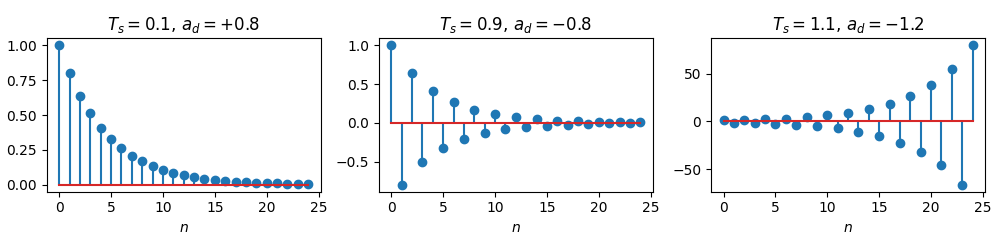

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 2.5))
for ax, T_s in zip(axes, (0.1, 0.9, 1.1)):
    q = euler_sim(a, T_s, 25)
    ax.stem(np.arange(25), q)
    ax.set_title(f"$T_s = {T_s}$, $a_d = {1 + T_s*a:+.1f}$"); ax.set_xlabel("$n$")
plt.tight_layout()

## C3: The reconstruction error of the zero-order hold *(↔ P2)*

The signal $x(t) = \sin(2\pi t)$ is compared with its sample-and-hold reconstruction on a fine time grid, and the largest deviation is computed for four sampling periods.

a) Complete the two lines that locate the sampling interval of each time $t$ and hold the most recent sample.

b) Run the check cell and the plot cell. Once $T_s$ is well below the period, the error decreases roughly in proportion to $T_s$; at $T_s = 1$ every sample lies on a zero crossing and the reconstruction misses the whole signal.

In [2]:
t = np.linspace(0, 2, 2001)
x = np.sin(2 * np.pi * t)

def zoh_error(T_s):
    n_idx = (t // T_s).astype(int)                 # the interval each t falls in
    zoh = np.sin(2 * np.pi * n_idx * T_s)          # hold the most recent sample
    max_abs_deviation = np.max(np.abs(x - zoh))
    return max_abs_deviation, zoh

for T_s in (0.25, 0.1, 0.02, 1.0):
    print(f"T_s={T_s}:  max ZOH error = {zoh_error(T_s)[0]:.3f}")

T_s=0.25:  max ZOH error = 1.000
T_s=0.1:  max ZOH error = 0.588
T_s=0.02:  max ZOH error = 0.125
T_s=1.0:  max ZOH error = 1.000


In [ ]:
e25, e10, e02, e1 = (zoh_error(T)[0] for T in (0.25, 0.1, 0.02, 1.0))
assert abs(e25 - 1.0) < 1e-3 and abs(e1 - 1.0) < 1e-3      # four samples per period, and the zero-crossing case
assert abs(e10 - 0.588) < 5e-3 and abs(e02 - 0.125) < 5e-3
assert 4 < e10 / e02 < 5                                   # roughly proportional to T_s
print("C3 passed: the hold error decreases with T_s once T_s is well below the period; at T_s = 1 it is the whole signal.")

C3 passed: the hold error decreases with T_s once T_s is well below the period; at T_s = 1 it is the whole signal.


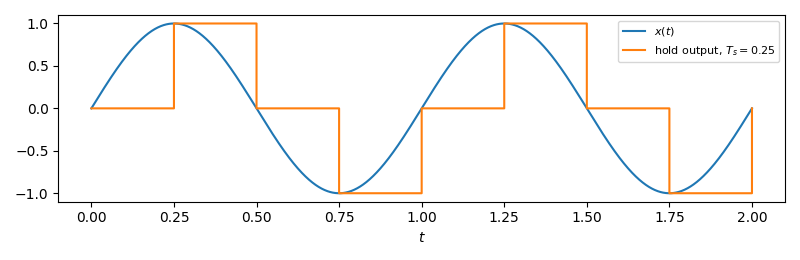

In [8]:
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(t, x, label="$x(t)$")
ax.step(t, zoh_error(0.25)[1], where="post", label="hold output, $T_s = 0.25$")
ax.set_xlabel("$t$"); ax.legend(fontsize=8)
plt.tight_layout()